# Линейная алгебра. Лабораторная работа 1, осень 2024



В этой лабораторной работе вы познакомитесь со средой Jupyter Notebook и библиотеками numpy и scipy.

## Часть 1. Библиотеки

В этой лабораторной работе вам понадобятся три библиотеки:

- `numpy` – основная библиотека для работы с матрицами;
- `scipy`, а точнее модуль `scipy.linalg`, содержащий множество функций линейной алгебры;
- `matplotlib` – графическая библиотека

Подключить их можно следующим образом:

In [ ]:
# Запустите этот код
import numpy as np

import scipy.linalg as sla

import matplotlib.pyplot as plt
%matplotlib inline

Теперь вы можете позвать, скажем, функцию `scipy.linalg.det()` с помощью кода `sla.det()`, а функцию `numpy.exp()` – с помощью кода `np.exp()`.

**Основные объекты и операции линейной алгебры в NumPy и SciPy:**

Основной объект, с которым вам придётся работать и в этой, и в следующих лабораторных, – это, безусловно, матрицы. В библиотеке `numpy` они представлены классом `numpy.ndarray`. Матрицу можно создать из двумерного (а на самом деле и не только двумерного) массива следующим образом:

In [ ]:
# Запустите этот код
A = np.array([[1, 2, 3], [4, 5, 6]])

print(A)
print(A.shape) # пара (число строк, число столбцов)

[[1 2 3]
 [4 5 6]]
(2, 3)


Обратите внимание, что матрица заполняется *по строкам*.

Есть и много других конструкторов матриц. Например, единичная матрица размера $n\times n$ создаётся с помощью функции `numpy.eye(n)`. Со всем многообразием конструкторов можно ознакомиться [на этой странице](https://docs.scipy.org/doc/numpy-1.10.1/reference/routines.array-creation.html).

Зачастую бывает нужно получить доступ к подматрицам данной матрицы, и numpy предоставляет множество удобных средств, как это сделать (вообще данная процедура называется slicing):
- элемент с номером `(i,j)`: `A[i,j]`
- i-я строка матрицы: `A[i,:]`
- j-й столбец матрицы: `A[:,j]`

**Внимание!** Оба варианта, и `A[i,:]`, и `A[:,j]` дают не строку или столбец, а одномерный вектор. Если вы хотите получить вектор-строку или вектор-столбец соответственно, используйте вот такой синтаксис: `A[i:i+1,:]` и `A[:,j:j+1]`
- строки с нулевой по i-ю: `A[:i+1,:]`
- столбцы с j-го по последний: `A[:,j:]`
- строки с i-й по k-ю: `A[i:k,:]`

В некоторых случаях нужно получить доступ к (прямоугольной) подматрице, элементы которой находятся на пересечении строк из списка `rows` и столбцов из списка `columns`. В этом случае `A[rows, columns]` даст не то, что вы ожидаете (можете попробовать это сделать сами и увидеть, что получится; только возьмите `rows` и `columns` одного размера). Справиться с этой задачей позволяет код `A[np.ix_(rows, columns)]`

*Умножение матриц* производится с помощью функции `np.dot()` либо оператора `@`. Есть три варианта написания: `A.dot(B)`, `np.dot(A, B)` и `A @ B`.

Обычные знаки арифметических действий (`+`, `-`, `*`) зарезервированы для поэлементных операций. Например, `A * B` – это матрица, элементами которой являются произведения $A_{ij}B_{ij}$. Помимо этих есть и множество других поэлементных операций. Например, `numpy.exp(A)` – это матрица, элементами которой являются экспоненты элементов матрицы `A`.

Чтобы получить матрицу, *транспонированную* к матрице `A`, напишите просто `A.T`.

В некоторых случаях бывает нужно создавать *случайные матрицы*: например, при проведении экспериментов или для инициализации итеративных методов. Средства для этого предоставляет пакет [numpy.random](https://docs.scipy.org/doc/numpy/reference/routines.random.html). Так, `np.random.rand(m,n)` – это матрица $m\times n$, элементы которой независимо выбраны из равномерного распределения на интервале `[0;1)`.

Для *решения систем линейных уравнений* в пакете `scipy.linalg` есть множество методов, рассмотрение которых выходит за пределы стандартного курса линейной алгебры. Мы вам пока предлагаем пользоваться функцией `scipy.linalg.solve`, основанной на методе Гаусса. Отметим, что `scipy.linalg.solve(A, B)` выдаёт решение уравнения $AX = B$ (или ошибку), где $B$ может быть как вектором, так и матрицей.

Найти обратную матрицу для матрицы $A$ можно с помощью функции `sla.inv(A)`.

**Копирование сложных объектов в Python**

Когда вы делаете присваивание каких-то сложных объектов, как правило, оно происходит по ссылке. Например, код
```
B = A
B[0,0] = 10
```
приведёт к изменению матрицы `A`.

Не попадайтесь в эту ловушку! Если вы хотите работать с копией как с независимой матрицей, используйте метод `copy()`:
```
B = A.copy()
```

**Где искать помощь**

Библиотеки `numpy` и `scipy` снабжены прекрасной документацией. Если у вас возникают вопросы о том, как работает та или иная функция (или даже как называется функция, выполняющая то, что вам нужно), вы почти всегда можете найти там ответы.

[Ссылка на документацию пакета scipy.linalg](https://docs.scipy.org/doc/scipy-0.18.1/reference/linalg.html)

Если у вас возникает какая-то ошибка и вы не можете понять, что вы делаете не так, то

1) в первую очередь попробуйте просто загуглить текст ошибки, наверняка в интернете кто-то уже сталкивался с такой ситуацией;  
2) поспрашивайте своих одногруппников, не было ли у них такой ошибки, и если была, то как они справлялись;  
3) попросите помощи у вашего учебного ассистента.




**И всё-таки задание**

**Задание 1.1 [0.2 балла за каждый пункт]** В качестве первого задания мы попросим вас отыскать соответствующие функции в библиотеке и сделать следующее:

- создайте нулевую матрицу $Z$ размера $3\times4$;

- создайте диагональную матрицу $5\times5$ с диагональными элементами 1, 2, 3, 4 и 5;

- найдите её след (не силою мысли, а с помощью библиотечных функций, конечно);

- найдите обратную к ней матрицу;

- сгенерируйте случайную матрицу $X$ размера $4\times5$;

- найдите определитель подматрицы матрицы $X$, расположенной на пересечении 2-й и 3-й строк и 1-го и 2-го столбцов; считаем, что строки и столбцы нумеруются с единицы (используйте slicing!). Такой определитель называется **минором** матрицы $X$;

- найдите произведение $X^TX$.

Пожалуйста, каждый пункт делайте в новом блоке и не забывайте распечатывать результаты.

In [ ]:
Z = np.zeros((3, 4))
print(Z)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [ ]:
D = np.diag(np.arange(1, 6))
print(D)

[[1 0 0 0 0]
 [0 2 0 0 0]
 [0 0 3 0 0]
 [0 0 0 4 0]
 [0 0 0 0 5]]


In [ ]:
tr = np.trace(D)
print(tr)

15


In [ ]:
InvD = sla.inv(D)
print(InvD)

[[ 1.          0.         -0.          0.         -0.        ]
 [ 0.          0.5        -0.          0.         -0.        ]
 [ 0.          0.          0.33333333  0.         -0.        ]
 [ 0.          0.          0.          0.25       -0.        ]
 [ 0.          0.          0.          0.          0.2       ]]


In [ ]:
X = np.random.rand(4, 5)
print(X)

[[0.4604402  0.71019135 0.99137935 0.34446351 0.80067035]
 [0.53601602 0.26522033 0.45363724 0.69123016 0.76084261]
 [0.70332462 0.06285848 0.37769897 0.73126032 0.407375  ]
 [0.8958693  0.05975141 0.84659016 0.44417024 0.52959942]]


In [ ]:
d = sla.det(X[np.ix_([1, 2], [0, 1])])
print(d)

-0.1528428353982084


In [ ]:
m = X.T.dot(X)
print(m)

[[1.79656568 0.56690237 1.72370686 1.44134716 1.53745338]
 [0.56690237 0.582235   0.8987094  0.50046902 0.82767138]
 [1.72370686 0.8987094  2.04799118 1.30728818 1.74113337]
 [1.44134716 0.50046902 1.30728818 1.3284831  1.33484856]
 [1.53745338 0.82767138 1.74113337 1.33484856 1.66638443]]


## Часть 2. Время

Питон мотивирует пользоваться библиотечными функциями, когда они доступны, а не писать собственные. Библиотечные функции основаны на современных алгоритмах, обычно пишутся на более эффективных языках, таких как C++ или Fortran, а кроме того, оптимизированы для работы на многопроцессорных устройствах, так что обогнать эти решения просто так вы не сможете.

**Задание 2.1 [1 балл]**
Мы предлагаем вам убедиться в этом самим. Напишите функцию `my_det`, которая вычисляла бы определитель матрицы с помощью элементарных преобразований над строками. Функция должна выкидывать `ValueError` в случаях, если матрица не является квадратной.

In [ ]:
def my_det(X):
    '''
    Parameters
    ----------
    X : array_like

    Returns
    -------
    det : float
        Determinant of `a`.
    '''
    Y = X.copy().astype(float)
    det = 1.0
    if Y.shape[0] != Y.shape[1]:
        raise ValueError
    size = Y.shape[0]
    for i in range(size):
        m = i
        for t in range(i+1, size):
            if Y[t, i] > Y[m, i]:
                m = t
        if m != i:
            Y[[i, m]] = Y[[m, i]]
            det *= -1
        if Y[i, i] == 0:
            return 0
        det *= Y[i, i]
        for j in range(i+1, size):
            kf = Y[j, i]/Y[i, i]
            Y[j, :] -= kf * Y[i, :]

    return det

Простая проверка:

In [ ]:
# Запустите этот блок кода
X = np.array([[0,0,1], [0,1,0], [1,0,0]])
print(my_det(X))

-1.0


На случай, если нам просто повезло с этой матрицей, имеет смысл написать чуть более хитрые тесты. Мы сгенерируем несколько случайных матриц $50\times50$ с помощью функции `numpy.random.rand` и сравним ответ, выдаваемый нашей функцией, с настоящим определителем (результатом работы библиотечной функции `scipy.linalg.det`):

In [ ]:
# Запустите этот блок кода
for _ in range(50):
    X = np.random.rand(50, 50)
    if np.abs(my_det(X) - sla.det(X)) > 1e-6:
        print('FAILED')

Если вы ни разу не получили `FAILED`, то ваша функция работает правильно.

Теперь давайте сравним скорость работы вашей функции и библиотечной функции `scipy.linalg.det`. В Питоне есть несколько способов измерения времени; мы воспользуемся декоратором `%timeit`. Будучи написан перед функцией, он запускает её некоторое количество раз, выбирает три случайных запуска и возвращает длительность самого быстрого из них. Модификатор `-o` между декоратором и функцией позволяет сохранять результаты работы декоратора в переменную.

Приготовьтесь, что следующий блок может работать сравнительно долго.

19.2 µs ± 1.24 µs per loop (mean ± std. dev. of 7 runs, 100000 loops each)
375 µs ± 64.1 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
129 µs ± 9.34 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)
32.3 ms ± 6.36 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
39.8 ms ± 1.04 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


<ipython-input-15-9dca1a7cbc2d>:27: RuntimeWarning: overflow encountered in scalar multiply
  det *= Y[i, i]


3.31 s ± 426 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


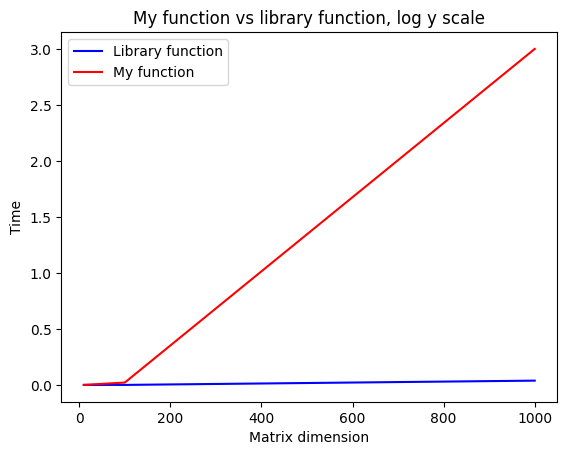

In [ ]:
# Запустите этот блок кода
lib_times = []
my_times = []
dimensions = [10, 100, 1000]
for dim in dimensions:
    A = np.random.rand(dim, dim)
    res_lib = %timeit -o sla.det(A)
    lib_times.append(res_lib.best)
    res_my = %timeit -o my_det(A)
    my_times.append(res_my.best)

plt.plot(dimensions, lib_times, color='blue', label='Library function')
plt.plot(dimensions, my_times, color='red', label='My function')
plt.title('My function vs library function, log y scale')
plt.ylabel('Time')
plt.xlabel('Matrix dimension')
plt.legend()

У вас должны были получиться графики, показывающие, как растёт с ростом размерности матрицы время вычисления определителя. Поскольку они вышли не больно-то красивыми, мы нарисуем их в *логарифмическом масштабе* по оси у:

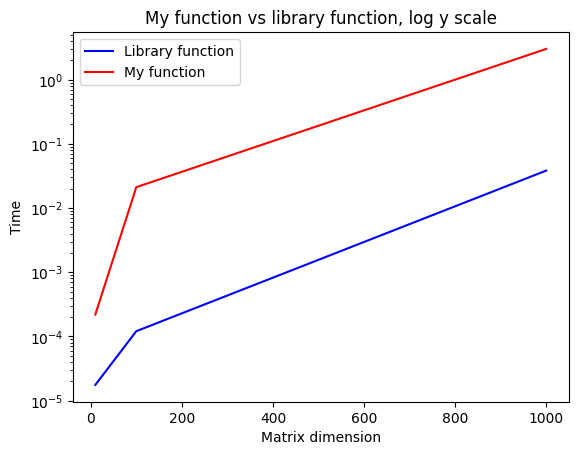

In [ ]:
# Запустите этот блок кода
plt.semilogy(dimensions, lib_times, color='blue', label='Library function')
plt.semilogy(dimensions, my_times, color='red', label='My function')
plt.title('My function vs library function, log y scale')
plt.ylabel('Time')
plt.xlabel('Matrix dimension')
plt.legend()

Вы можете убедиться, что библиотечная функция работает *гораздо* быстрее.

## Часть 3. Точность

Наверняка вы уже что-то знаете про floating point arithmetics и связанные с этим трудности и понимаете, что на компьютере вычисления с вещественными числами производятся лишь с ограниченной точностью.

**Задание 3.1 [0.6 балла]** В качестве первого примера, показывающего различие между длинной арифметикой целых чисел и floating point arithmetics, предлагаем вам перемножить две пары матриц:

$$
\begin{pmatrix}
1 & 0\\
10^{20} & 1
\end{pmatrix}
\cdot
\begin{pmatrix}
10^{-20} & 1\\
0 & 1 - 10^{20}
\end{pmatrix}
$$
и
$$
\begin{pmatrix}
1. & 0.\\
10.^{20} & 1.
\end{pmatrix}
\cdot
\begin{pmatrix}
10.^{-20} & 1.\\
0. & 1. - 10.^{20}
\end{pmatrix}
$$
Во втором случае мы специально указали Питону (поставив везде десятичные точки), что хотим работать не с целыми числами, а с числами с плавающей точкой. Посмотрим, получатся ли одинаковые ответы:

In [ ]:
A = np.array([[1, 0], [10**20, 1]])
B = np.array([[10**(-20), 1], [0, 1 - 10**20]])
A1 = np.array([[1., 0.], [10.**20, 1.]])
B1 = np.array([[10.**(-20), 1.], [0., 1. - 10.**20]])
m = A.dot(B)
print(m)
m1 = A1.dot(B1)
print(m1)

[[1e-20 1]
 [1.0 1]]
[[1.e-20 1.e+00]
 [1.e+00 0.e+00]]


И какой из них правильный?

---
Первый (во втором случае значение `m1[2][2]` неверное, оно должно быть равно $10^{20}$ + 1 - $10^{20}$ = 1)

**Задание 3.2 [0.75 балла]** Впрочем, и с целыми числами тоже не всегда всё хорошо. Напишите функцию, генерирующую *матрицу Паскаля* заданной размерности $n$, то есть матрицу $P$, в которой $P_{ij} = C_{i+j}^i$. В этом задании нельзя пользоваться библиотечной функцией `scipy.linalg.pascal` или её аналогами из других библиотек. Обратите внимание, что использование факториалов крайне нежелательно, так как быстро приведёт к переполнению.

В этом задании вы можете использовать цикл ``for``.

In [ ]:
def my_pascal(dim):
    '''
    Мы создали для вас матрицу из нулей размера dim x dim,
    но вы можете ей не пользоваться, если не хотите
    '''
    P = np.zeros((dim, dim))

    for i in range(dim):
      for j in range(dim):
        if j == 0 or i == 0:
          P[i][j] = 1
        else:
          P[i][j] = P[i-1][j] + P[i][j-1]

    return P

Чему равен её определитель? **Строго** поясните свой ответ.

----
Ответ: 1\
Воспользуемся доказательством по индукции.\
Докажем, что определитель всех квадратных матриц A (в том числе и матриц Паскаля), у которых каждый элемент `A[i][j]` кроме первой строки и первого столбца равен `A[i-1][j]` + `A[i][j-1]`, а в первом столбце находятся только единицы, равен 1.\
Введем обозначение: $A_{n}$ - матрица A размера $n\times n$\, имеющая описанные выше свойства.\
База индукции: det($A_{1}$) = 1\
Шаг индукции: пусть det($A_{n}$) = 1\
Докажем, что det($A_{n+1}$) = 1:\
Воспользуемся элементарными преобразованиями строк первого типа (определитель матрицы при этом не изменится). Вычтем из n+1-ой строки n-ю, из n-ой n-1-ю, ..., из 2-ой 1-ю. После этого матрица А будет иметь вид `A[0][0]` = 1, а все остальные элементы певого столбца - нулевые. Заметим, что матрица размера $n\times n$ со второй строки до последней и со второго столбца до последнего, является матрицей  $A_{n}$ (её определитель равен 1 по предположению индукции). Разложив матрицу $A_{n+1}$ по первому столбцу, получим det($A_{n+1}$) = $1 \cdot$ det( $A_{n}$) = 1.\
То есть определитель матрицы $A_{n+1}$ равен определителю матрицы $A_{n}$.\
Таким образом, определители матриц A любого размера равны, а значит они равны определителю матрицы $A_{1}$, то есть равны 1.

А теперь вычислите определитель матрицы Паскаля $30\times30$ с помощью библиотечной функции `scipy.linalg.det`:

In [ ]:
P = my_pascal(30)
print(sla.det(P))

-3.400444993542751e+51


Разница заметна невооружённым взглядом!

## Часть 4. Матричные вычисления

Вы уже видели, что использования циклов (и самописных вычислений в целом) в Питоне лучше по возможности избегать, и важно уметь находить способы делать всё библиотечными средствами.

В качестве примера рассмотрим две задачи:

**1.** Предположим, нужно вычислить суммы элементов в каждой строке матрицы `A`. Ясно, что можно написать простую функцию с двумя циклами, которая это посчитает, но так лучше не делать. Правильный способ такой:
```
A.sum(axis=1)
```
Параметр `axis=1` означает, что суммы берутся по строкам. Если вы хотите просуммировать по столбцам, укажите `axis=0`. Если вообще пропустить параметр `axis` (вызвать `A.sum()`), то функция вернёт сумму *всех* элементов матрицы.

**2.** Теперь допустим, что нам нужно каждый столбец матрицы `A` умножить на некоторое число. Более точно, пусть у нас есть (одномерный) вектор `w = np.array([w_1,...,w_n])`, и мы должны `i`-й столбец `A` умножить на число `w_i`. Опять же, это можно сделать в пару циклов, но лучше использовать операцию поэлементного умножения:
```
A * w.reshape((1,n))
```
Оператор `reshape` нужен для того, чтобы из одномерного вектора сделать вектор-строку.

Аналогично, если на числа `w_1,...,w_n` умножаются *строки* матрицы, нужно превратить `w` в вектор-столбец:
```
A * w.reshape((n,1))
```

Дальше вам будет предложено попрактиковаться в матричных вычислениях. В следующих трёх заданиях нельзя пользоваться циклами, а также конструкциями `map` и `reduce` и им подобными; вместо этого постарайтесь свести всё к матричным операциям из `numpy` (но, опять же, не `np.vectorize` или чему-то подобному). Чтобы убедиться, что получилось именно то, что нужно, пишите собственные тесты со случайными матрицами.

**Задание 4.1 [0.75 балла]** Напишите функцию `prod_and_sq_sum(A)`, вычисляющую произведение диагональных элементов, а также сумму квадратов диагональных элементов квадратной матрицы `A`.

In [ ]:
def prod_and_sq_sum(A):
    d = np.diag(A)
    p = d.prod()
    d = d * d
    return p, d.sum()

**Задание 4.2 [0.75 балла]** Для матриц `A` и `B` размера $m\times n$ обозначим через $a_1,\ldots,a_n$ и $b_1,\ldots,b_n$ соответственно их столбцы; пусть также $\lambda_1, \ldots, \lambda_n$ – некоторые числа. Напишите функцию `f(A, B, lmbd, k)`, вычисляющую

$$\sum_{i=1}^{\min(k,n)}\lambda_ia_ib_i^T$$

In [ ]:
def f(A, B, lmbd, k):
    m, n = A.shape
    s = min(k, n)
    A_s = A[:, :s]
    B_s = B[:, :s]
    lmbd_s = lmbd[:s].reshape((1, s))
    ans = (A_s * lmbd_s) @ (B_s.T)
    return ans

In [ ]:
# Проверка
A = np.array([[3,5,1], [0,1,2], [1,1,1]])
B = np.array([[0,6,1], [1,1,3], [1,7,9]])
l = np.array([1, 2, 3, 4])
print(f(A, B, l, 2))

[[60 13 73]
 [12  2 14]
 [12  3 15]]


**Задание 4.3 [0.75 балла]** Напишите функцию `get_diag(A,B)`, принимающую две квадратных матрицы матрицы `A` и `B` одного размера и возвращающую вектор диагональных элементов произведения `AB`, не вычисляя произведение целиком.

In [ ]:
def get_diag(A, B) :
    res = np.sum(A * B.T, axis=1)
    return res

## Часть 5. Комплексные числа и геометрия

У вас уже была возможность убедиться, что многие операции над комплексными числами имеют наглядную геометрическую интерпретацию. В этом задании вам будет предложено этим воспользоваться.

В Python число $i$ (мнимая единица) обозначено через `1j`. Так, число $0,5 + 1,2i$ будет иметь вид `0.5 + 1.2 * 1j`.

При выполнении задания вы должны работать с точками плоскости как с комплексными числами. Любые преобразования должны быть реализованы с помощью операций над комплексными числами: сложения, вычитания, умножения, деления, возведения в степень и комплексного сопряжения.

**Задание 5.1 [0.5 баллов]** Напишите функцию `shrink_rotate`, которая принимает на вход:
- заданную в виде комплексного числа точку $X$, которую мы подвергаем преобразованию,
- заданную в виде комплексного числа точку $A$,
- действительный коэффициент `coef`,
- угол `alpha`, заданный в радианах

и осуществляет следующее преобразование: мы берём вектор $AX$, умножаем его на `coef`, поворачиваем вокруг точки $A$ на угол `alpha` против часовой стрелки, после чего возвращаем конец полученного вектора. Ниже (левая картинка) мы приводим иллюстрацию действия этого преобразования:

<img src="ShrinkRotate.png">

**Задание 5.2 [0.5 баллов]** Напишите функцию `shrink_rotate_conj`, которая сначала делает то же самое, что и `shrink_rotate`, а после этого отражает вектор $AY$ относительно горизонтальной прямой, проходящей через точку $A$, и возвращает точку $Y'$ (см. правую часть рисунка).

**Задание 5.3 [0.5 баллов]** Напишите функцию `geometric_inverse`, которая принимает на вход:
- заданную в виде комплексного числа точку $X$, которую мы подвергаем преобразованию,
- заданную в виде комплексного числа точку $A$,
- положительное действительное число $r$

и осуществляет инверсию точки $X$ относительно окружности с центром $A$ радиуса $r$. [Определение инверсии вы можете посмотреть здесь](https://ru.wikipedia.org/wiki/%D0%98%D0%BD%D0%B2%D0%B5%D1%80%D1%81%D0%B8%D1%8F_(%D0%B3%D0%B5%D0%BE%D0%BC%D0%B5%D1%82%D1%80%D0%B8%D1%8F)).

In [ ]:
import cmath
def shrink_rotate(x, a, coef=1., angle=0.):
    AX = x - a
    r, phi = cmath.polar(AX)
    rotated_vector = cmath.rect(r * coef, phi + angle)
    A_new = a + rotated_vector
    return A_new
    raise NotImplementedError()

def shrink_rotate_conj(x, a, coef=1., angle=0.):
    Y = shrink_rotate(x, a, coef, angle)
    Y_new = complex(Y.real, 2 * a.imag - Y.imag)
    return Y_new
    raise NotImplementedError()

def geometric_inverse(x, a, r):
    AX = X - A
    conjugate_vector = AX.conjugate()
    X_new = a + (r**2 / conjugate_vector)
    return X_new
    raise NotImplementedError()

**Задание 5.4 [0.75 баллов]** Рассмотрим следующий процесс:

```
z = 0.5 + 0.*1j
max_iter = 100000
funcs = [
    (lambda t: shrink_rotate(t, 0. + 1.*1j, coef=0.5, angle=0.)),
    (lambda t: shrink_rotate(t, 1. + 0.*1j, coef=0.5, angle=0.)),
    (lambda t: shrink_rotate(t, -1. + 0.*1j, coef=0.5, angle=0.))
]

for n_iter in range(max_iter):
    n_func = np.random.choice(len(funcs))
    z = funcs[n_func](z)
```

Запустите его и нарисуйте множество точек, получающихся на итерациях начиняя с десятой.

*Указание*. Представьте квадрат $[-1,1]\times[-1,1]$ матрицей пикселей 1000x1000. Сначала все элементы матрицы положим нулями, а на каждой итерации начиная с десятой будем присваивать единицу соответствующему пикселю этой матрицы. То, что получилось, можно нарисовать с помощью функции `plt.imshow(..., cmap='gray')`. Картинку лучше сделать побольше, предварив `imshow` вызовом `plt.figure(figsize=(20, 20))`.

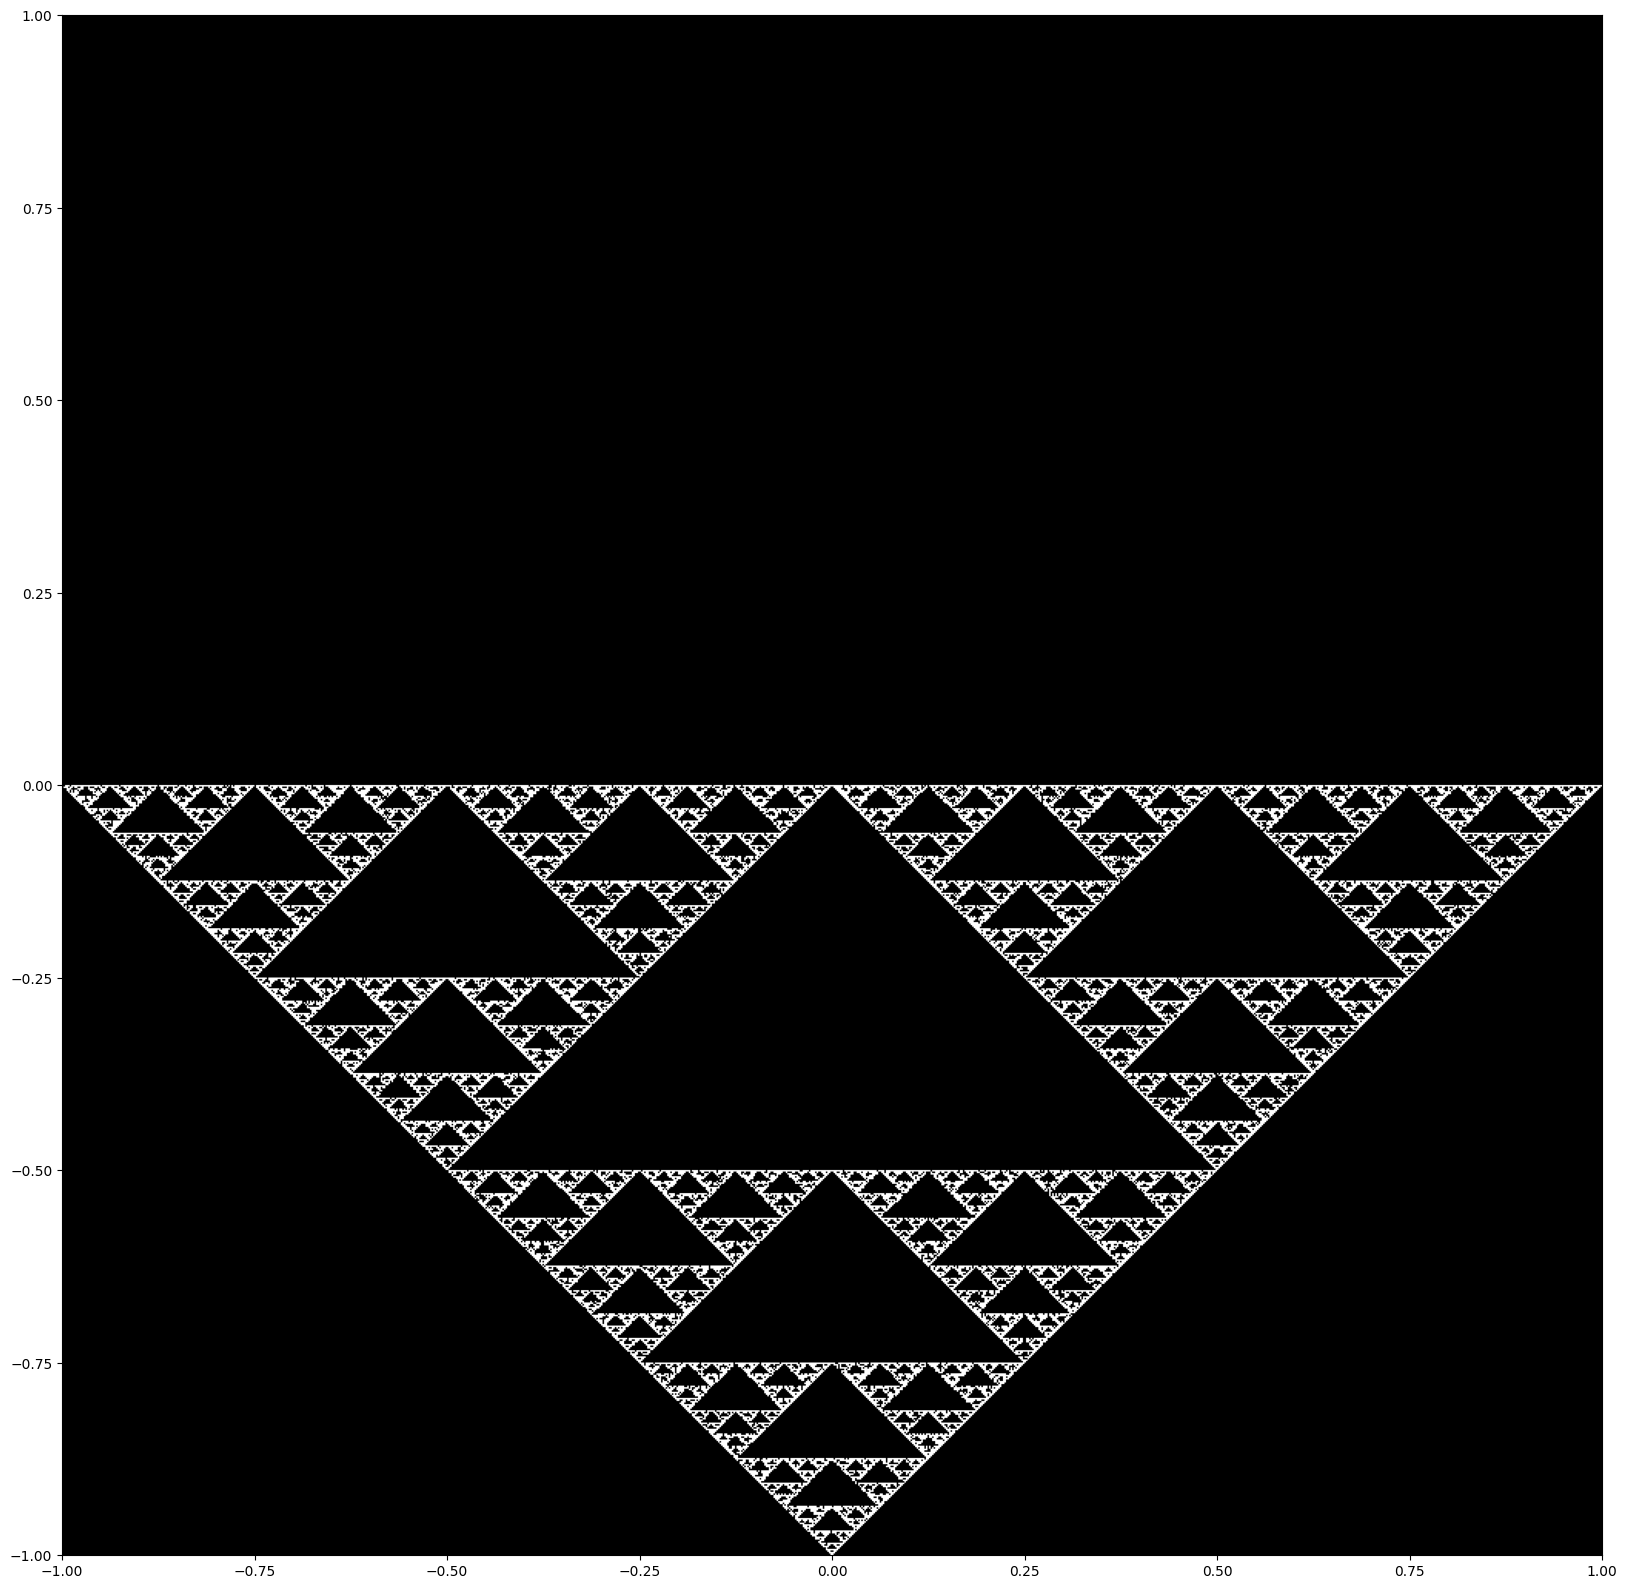

In [ ]:
image = np.zeros((1000, 1000))
x_min, x_max = -1, 1
y_min, y_max = -1, 1
z = 0.5 + 0.*1j
max_iter = 100000
funcs = [
    (lambda t: shrink_rotate(t, 0. + 1.*1j, coef=0.5, angle=0.)),
    (lambda t: shrink_rotate(t, 1. + 0.*1j, coef=0.5, angle=0.)),
    (lambda t: shrink_rotate(t, -1. + 0.*1j, coef=0.5, angle=0.))
]

for n_iter in range(max_iter):
    n_func = np.random.choice(len(funcs))
    z = funcs[n_func](z)
    if n_iter >= 10:
      x = int((z.real - x_min) * 1000 / (x_max - x_min))
      y = int((z.imag - y_min) * 1000 / (y_max - y_min))
      if 0 <= x < 1000 and 0 <= y < 1000:
        image[y, x] = 1
plt.figure(figsize=(20, 20))
plt.imshow(image, cmap='gray', extent=(x_min, x_max, y_min, y_max))
plt.show()

**Задание 5.5 [0.75 баллов]** Попробуйте объяснить, почему получается именно эта фигура.

---
Точки $i$, $1$, $-1$ являются вершинами треугольника, поэтому получается фигура, состоящая из треугольников.

**Задание 5.6 [0.5 баллов]** Поэкспериментируйте с другими преобразованиями. Попробуйте найти какой-нибудь другой красиво выглядящий фрактал.

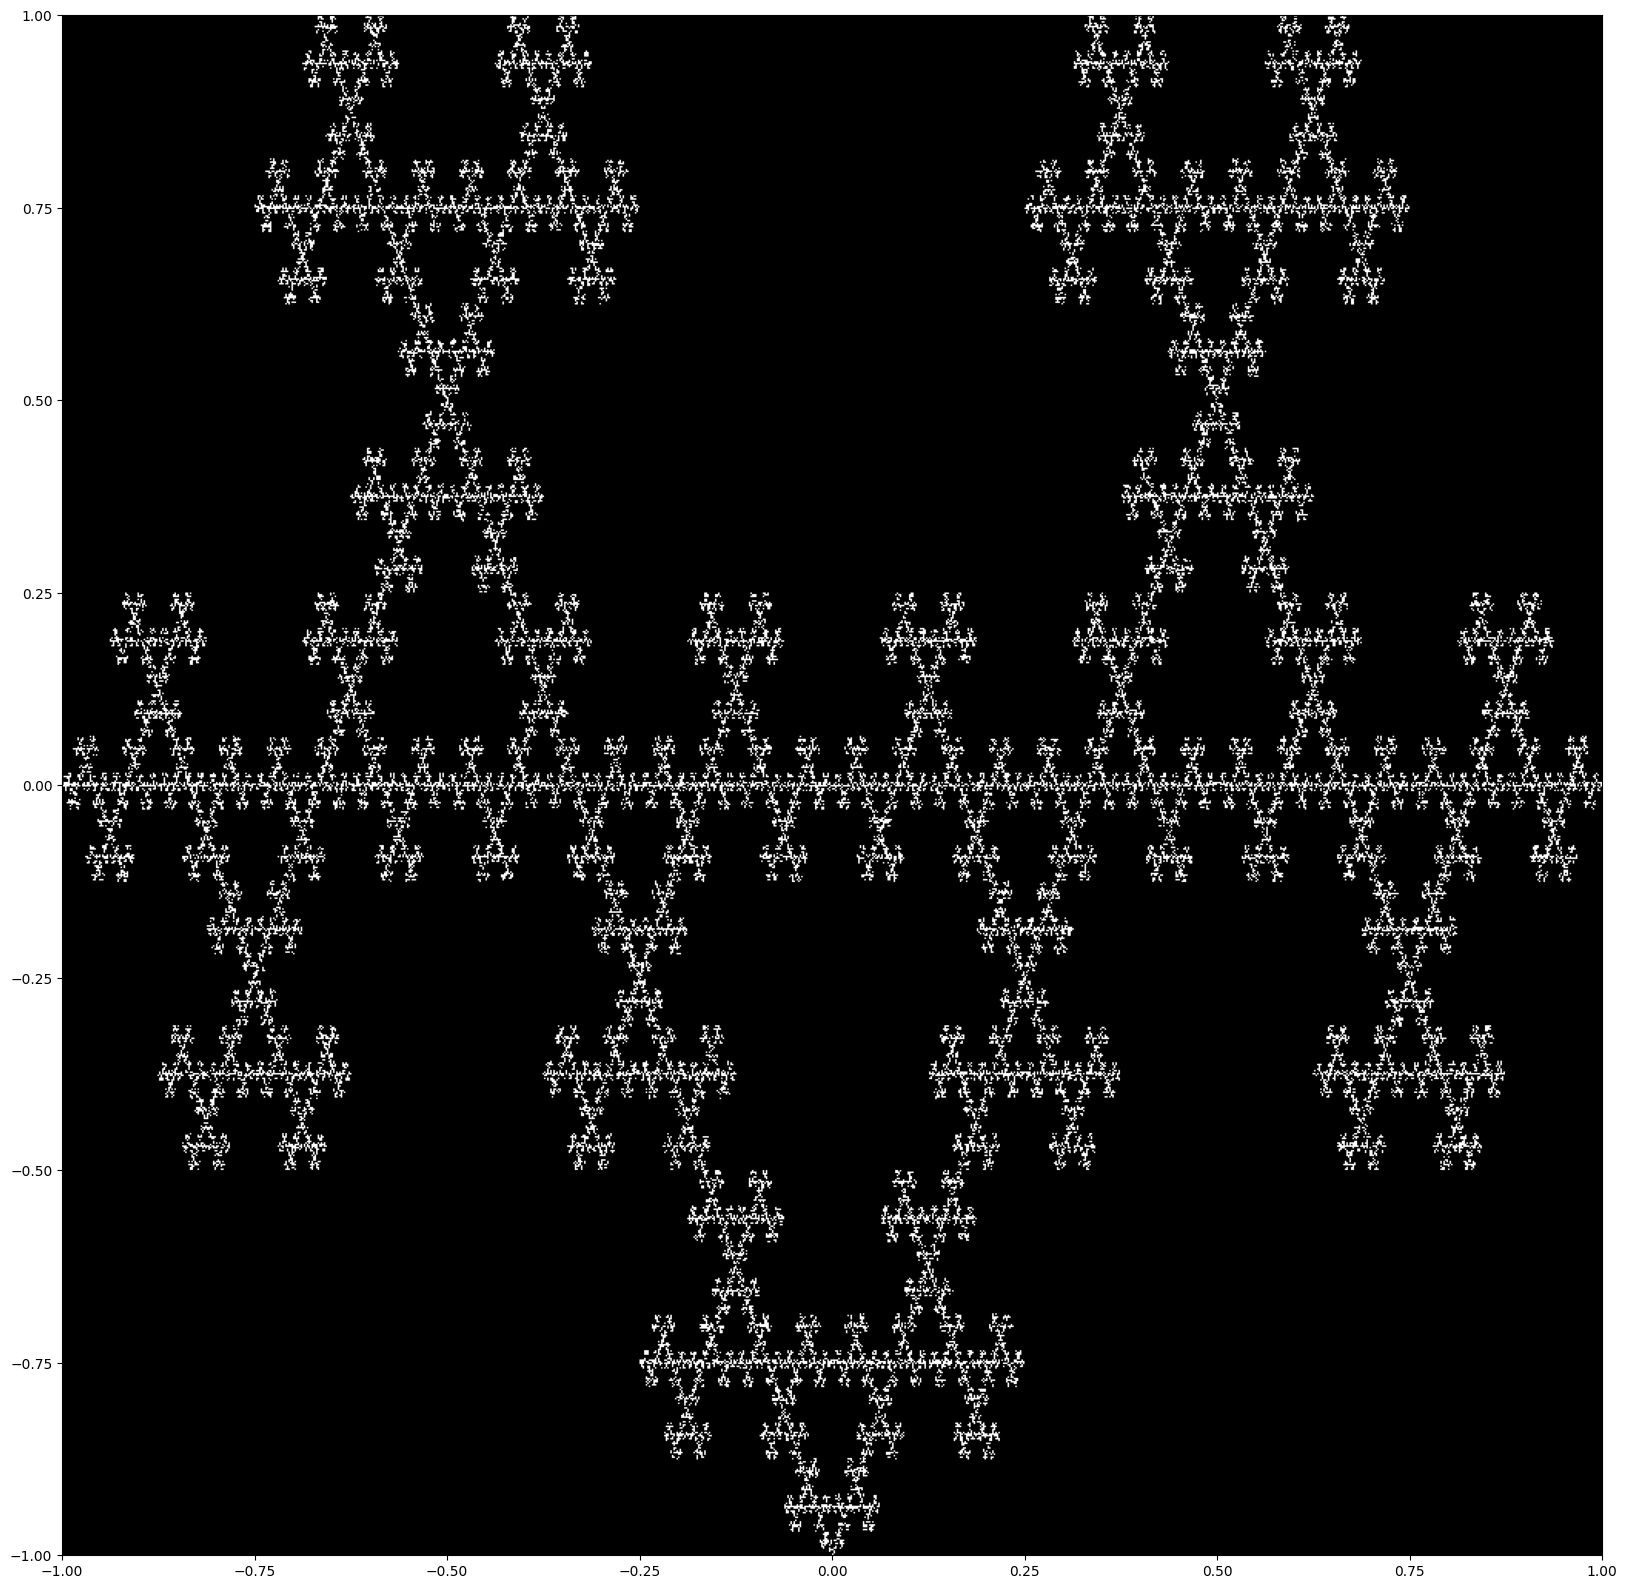

In [ ]:
image = np.zeros((1000, 1000))
x_min, x_max = -1, 1
y_min, y_max = -1, 1
z = 0.5 + 0.*1j
max_iter = 100000
funcs = [
    (lambda t: shrink_rotate_conj(t, 0. + 1.*1j, coef=0.5, angle=0.)),
    (lambda t: shrink_rotate_conj(t, 1. + 0.*1j, coef=0.5, angle=0.)),
    (lambda t: shrink_rotate_conj(t, -1. + 0.*1j, coef=0.5, angle=0.))
]

for n_iter in range(max_iter):
    n_func = np.random.choice(len(funcs))
    z = funcs[n_func](z)
    if n_iter >= 10:
      x = int((z.real - x_min) * 1000 / (x_max - x_min))
      y = int((z.imag - y_min) * 1000 / (y_max - y_min))
      if 0 <= x < 1000 and 0 <= y < 1000:
        image[y, x] = 1
plt.figure(figsize=(20, 20))
plt.imshow(image, cmap='gray', extent=(x_min, x_max, y_min, y_max))
plt.show()

## Часть 6 (бонус). Метод Гаусса или обратные матрицы?

**Задание 6.1 [1.5 балла]** Пусть нам дано матричное уравнение $Ax = B$, где $A$ – матрица размера $n\times n$, а $B$ – матрица размера $n\times m$ (отметим, что это уравнение можно интерпретировать как $m$ систем с векторными правыми частями и однаковыми левыми). Вообще говоря, методов решения таких уравнений очень много, но мы пока рассмотрим два из них, с которыми вы уже хорошо знакомы.
1. Метод Гаусса;
2. Умножение на обратную матрицу: $x = A^{-1}B$.

В этом задании вы попробуете ответить на вопрос о том, какой из этих методов эффективнее. Проведите два эксперимента:
- сравните скорости решения системы при фиксированном `m = 10` и `n`, изменяющемся в пределах от 10 до 1000, например, для `n=10, 50, 100, 200, 500, 1000` (рост числа неизвестных при фиксированном количестве правых частей);
- сравните скорости решения системы при фиксированном `n = 100` и `m`, меняющемся от 10 до 10000, например, для `m = 10, 100, 500, 1000, 2000, 5000, 10000` (рост числа правых частей при фиксированном числе неизвестных).

При проведении экспериментов не возбраняется использовать циклы `for`.

Эксперименты проведите на случайных матрицах, созданных с помощью функции `numpy.random.rand`. Постройте графики времени выполнения функции от размерности (лучше в логарифмическом масштабе). Сделайте выводы (в письменном виде!) о том, какой из методов оказывается лучше в каких обстоятельствах.

Чтобы всё это не казалось вам чёрной магией, найдите число операций (суммарно сложения, умножения и деления), необходимых для решения системы каждым из методов. Обратите внимания на члены суммарной степени 3 (суммарной по $m$ и $n$; члены меньшего порядка можете даже не считать). Постарайтесь объяснить полученные ранее результаты.

22.1 µs ± 1.29 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)
29.5 µs ± 5.33 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)
90.9 µs ± 11.3 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)
114 µs ± 27 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)
264 µs ± 8.64 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
531 µs ± 12.8 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
1.32 ms ± 497 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
10.4 ms ± 5.91 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
9.87 ms ± 122 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
79.5 ms ± 33.7 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
46.3 ms ± 1.5 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
184 ms ± 9.66 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


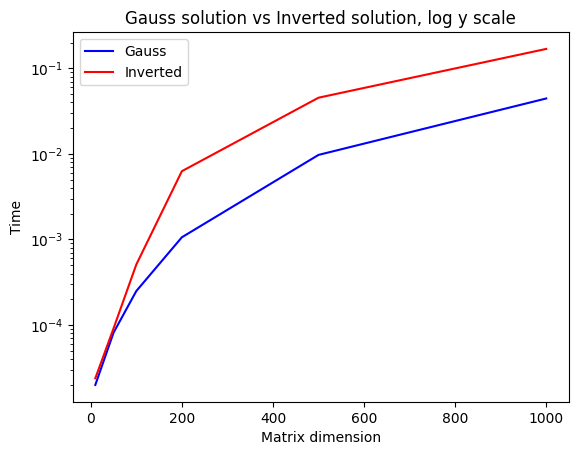

In [ ]:
gauss_times = []
inverted_times = []
m = 10
dimensions = [10, 50, 100, 200, 500, 1000]
for dim in dimensions:
    A = np.random.rand(dim, dim)
    B = np.random.rand(dim, m)
    res_gauss = %timeit -o np.linalg.solve(A, B)
    gauss_times.append(res_gauss.best)
    res_inverted = %timeit -o (sla.inv(A)).dot(B)
    inverted_times.append(res_inverted.best)

plt.semilogy(dimensions, gauss_times, color='blue', label='Gauss')
plt.semilogy(dimensions, inverted_times, color='red', label='Inverted')
plt.title('Gauss solution vs Inverted solution, log y scale')
plt.ylabel('Time')
plt.xlabel('Matrix dimension')
plt.legend()

При фиксированном m = 10, метод Гауса работает эффективнее, чем поиск обратной матрицы.\
При увеличении n во время поиска обратной матрицы мы выполняем больше алгебраических операций, чем во время метода Гаусса, поэтому время решения через обратную матрицу дольше, чем через метод Гаусса.

266 µs ± 17.5 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
The slowest run took 4.27 times longer than the fastest. This could mean that an intermediate result is being cached.
942 µs ± 637 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
464 µs ± 10.5 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
The slowest run took 12.68 times longer than the fastest. This could mean that an intermediate result is being cached.
4.54 ms ± 4.94 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
1.76 ms ± 621 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
4.61 ms ± 1.32 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
5.71 ms ± 915 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
5.61 ms ± 1.25 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
5.28 ms ± 231 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
10.9 ms ± 4.47 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
15.8 ms ± 4.42 ms per loop (mean ± std. dev. of

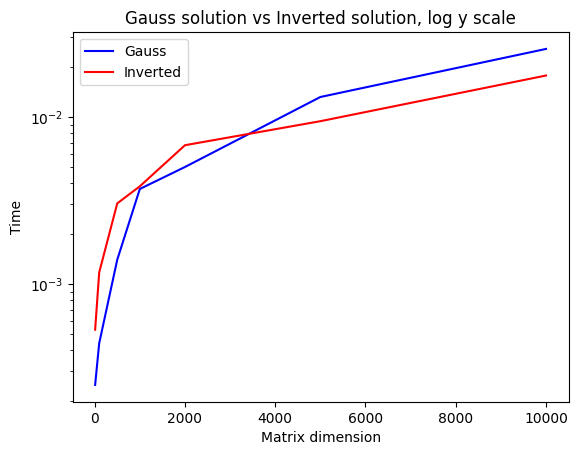

In [ ]:
gauss_times = []
inverted_times = []
n = 100
dimensions = [10, 100, 500, 1000, 2000, 5000, 10000]
for dim in dimensions:
    A = np.random.rand(n, n)
    B = np.random.rand(n, dim)
    res_gauss = %timeit -o np.linalg.solve(A, B)
    gauss_times.append(res_gauss.best)
    res_inverted = %timeit -o (sla.inv(A)).dot(B)
    inverted_times.append(res_inverted.best)

plt.semilogy(dimensions, gauss_times, color='blue', label='Gauss')
plt.semilogy(dimensions, inverted_times, color='red', label='Inverted')
plt.title('Gauss solution vs Inverted solution, log y scale')
plt.ylabel('Time')
plt.xlabel('Matrix dimension')
plt.legend()

При фиксированном n = 100, эффективнее искать обратную матрицу (в этом случае метод Гаусса работает быстрее только при небольших m).\
Время поиска обратной матрицы не зависит от меняющегося (увеличивающегося) значения m, от m зависит только время умножения матриц $A^{-1}$ и B.\
Что касается метода Гаусса, то время приведения к улучшенному ступенчатому виду всегда зависит от m (время выполнения операций растет с увеличением m).